### What will you learn from this project?
In this project, you will learn:

- How to transform large-scale transaction-level card data into customer-level features
- How to apply RFM (Recency, Frequency, Monetary) analysis to measure customer loyalty
- How to interpret purchasing patterns across merchant categories
- How to segment customers based on behavioral and transactional characteristics
- How CRM analytics can support customer retention, targeting, and value-based decision making
- How to translate analytical results into business-oriented insights for marketing and loyalty strategies

# Introduction
In today’s highly competitive financial and retail ecosystem, understanding customer purchasing behavior is a key driver of effective CRM and loyalty strategies. Customers interact with a wide variety of merchants across different categories, and these transaction patterns provide valuable signals about customer preferences, engagement, and long-term value.

This project focuses on analyzing transaction-level card data from the Elo Merchant Category Recommendation dataset to uncover insights into customer loyalty and purchasing behavior. By leveraging historical and new merchant transaction records, we aim to quantify how frequently customers interact with merchants, how recently they have transacted, and how their spending behavior evolves over time.

Using a CRM analytics perspective, this study applies RFM (Recency, Frequency, Monetary) analysis and customer-level aggregation techniques to segment customers based on their behavioral patterns. These segments are then interpreted to support customer value assessment, retention strategies, and data-driven marketing decisions.

Rather than focusing solely on merchant recommendation, this project reframes the dataset as a customer loyalty and value analysis problem, demonstrating how large-scale transaction data can be transformed into actionable CRM insights for financial services and retail-driven businesses.

# Analysis Content

1. [Python Libraries](#python-libraries)
2. [Data Loading](#data-loading)


<a id="python-libraries"></a>
# Python Libraries

In [1]:
!pip install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 15.2 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from sklearn.preprocessing import MinMaxScaler


# Dataset Columns Description

| Column | Description |
|--------|-------------|
| authorized_flag | Indicates whether the transaction was authorized or not. |
| card_id | Unique identifier for each customer card. |
| city_id | Identifier of the city where the transaction took place. |
| category_1 | Binary categorical feature representing a transaction type. |
| installments | Number of installments for the transaction. |
| category_3 | Categorical feature indicating merchant-related characteristics. |
| merchant_category_id | Identifier of the merchant's category. |
| merchant_id | Unique identifier for the merchant. |
| month_lag | Number of months before or after the reference month when the transaction occurred. |
| purchase_amount | Transaction amount normalized by Elo. |
| purchase_date | Date and time when the transaction occurred. |
| category_2 | Categorical feature related to merchant or transaction type. |
| state_id | Identifier of the state where the transaction occurred. |
| subsector_id | Identifier of the merchant’s business subsector. |

<a id="data-loading"></a>
# Data Loading

In [3]:
hist = pd.read_csv("/kaggle/input/elo-merchant-category-recommendation/historical_transactions.csv")
new = pd.read_csv("/kaggle/input/elo-merchant-category-recommendation/new_merchant_transactions.csv")
train = pd.read_csv("/kaggle/input/elo-merchant-category-recommendation/train.csv")


In [4]:
print("Historical:", hist.shape)
print("New:", new.shape)
print("Train:", train.shape)

Historical: (29112361, 14)
New: (1963031, 14)
Train: (201917, 6)


Looking at the dataset sizes, the first thing that stands out is how heavily transaction-driven this data is. While the `train` dataset contains around 200K customers, the historical transactions table alone has more than 29 million rows. This clearly shows that customer behavior is recorded at a very granular, transaction level.

This structure means that we cannot directly analyze customers using the raw transaction data. To make sense of loyalty, engagement, and value, we need to summarize these millions of transactions at the customer level. This is exactly why customer-level aggregation becomes a necessary step before applying RFM or moving toward CLTV analysis.

The new merchant transactions dataset, although smaller, still provides important signals about how customer behavior continues and evolves over time. Overall, this initial size comparison helps clarify why the project focuses on transforming transaction-level data into customer-level insights from a CRM perspective.


In [5]:
hist.columns

Index(['authorized_flag', 'card_id', 'city_id', 'category_1', 'installments',
       'category_3', 'merchant_category_id', 'merchant_id', 'month_lag',
       'purchase_amount', 'purchase_date', 'category_2', 'state_id',
       'subsector_id'],
      dtype='object')

In [6]:
hist.head()

,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id
0,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-8,-0.703331,2017-06-25 15:33:07,1.0,16,37
1,Y,C_ID_4e6213e9bc,88,N,0,A,367,M_ID_86ec983688,-7,-0.733128,2017-07-15 12:10:45,1.0,16,16
2,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_979ed661fc,-6,-0.720386,2017-08-09 22:04:29,1.0,16,37
3,Y,C_ID_4e6213e9bc,88,N,0,A,560,M_ID_e6d5ae8ea6,-5,-0.735352,2017-09-02 10:06:26,1.0,16,34
4,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-11,-0.722865,2017-03-10 01:14:19,1.0,16,37


After inspecting the columns and a few sample rows, it’s clear that this dataset is transaction-oriented: each row represents a single purchase linked to a customer (`card_id`), not a pre-aggregated customer record.

For CRM-focused analysis, transaction timing (`purchase_date`, `month_lag`) is critical for recency metrics, while `purchase_amount` reflects spending behavior. The `authorized_flag` variable is typically used as a data-quality filter to keep only approved transactions. In our initial check on the historical transactions data, the records appear to be overwhelmingly (or entirely) authorized, but validating this step is still a good practice.

Overall, the key takeaway is that the dataset must be aggregated to the customer level before applying RFM segmentation and later CLTV modeling.



In [7]:
use_cols = [
    "card_id",
    "purchase_date",
    "purchase_amount",
    "authorized_flag"]

hist = pd.read_csv(
    "/kaggle/input/elo-merchant-category-recommendation/historical_transactions.csv",
    usecols=use_cols)

In [8]:
df=hist.copy()

In [9]:
df.head()

,authorized_flag,card_id,purchase_amount,purchase_date
0,Y,C_ID_4e6213e9bc,-0.703331,2017-06-25 15:33:07
1,Y,C_ID_4e6213e9bc,-0.733128,2017-07-15 12:10:45
2,Y,C_ID_4e6213e9bc,-0.720386,2017-08-09 22:04:29
3,Y,C_ID_4e6213e9bc,-0.735352,2017-09-02 10:06:26
4,Y,C_ID_4e6213e9bc,-0.722865,2017-03-10 01:14:19


In [10]:
df.tail()

,authorized_flag,card_id,purchase_amount,purchase_date
29112356,Y,C_ID_2863d2fa95,-0.632706,2017-01-20 08:52:04
29112357,Y,C_ID_2863d2fa95,-0.632706,2017-02-20 04:40:50
29112358,Y,C_ID_5c240d6e3c,-0.657740,2017-12-26 18:37:51
29112359,Y,C_ID_5c240d6e3c,0.770620,2017-11-24 14:18:15
29112360,Y,C_ID_5c240d6e3c,1.134411,2017-10-26 14:09:40


In [11]:
df.shape

(29112361, 4)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29112361 entries, 0 to 29112360
Data columns (total 4 columns):
 #   Column           Dtype  
---  ------           -----  
 0   authorized_flag  object 
 1   card_id          object 
 2   purchase_amount  float64
 3   purchase_date    object 
dtypes: float64(1), object(3)
memory usage: 888.4+ MB


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
purchase_amount,29112361.0,0.036401,1123.521648,-0.746908,-0.720356,-0.688349,-0.603254,6.010604e+06


Looking at the distribution of `purchase_amount`, we observe that although the mean is very small (0.036), the maximum value exceeds 6 million. This indicates the presence of extreme outliers in the dataset.This indicates the presence of extreme outliers in the dataset. 
The large gap between the median (-0.688) and the maximum value, along with the extremely high standard deviation (1123), suggests that the distribution is heavily skewed.
Before performing RFM analysis, especially when calculating the Monetary metric, it is essential to handle these outliers using techniques such as clipping or winsorization. Otherwise, a small number of extreme transactions may disproportionately influence customer segmentation results.

In [14]:
df.isnull().sum()

authorized_flag    0
card_id            0
purchase_amount    0
purchase_date      0
dtype: int64

# Data Preprocessing

In [15]:
df = df[df["authorized_flag"] == "Y"]

In [16]:
df.head()

,authorized_flag,card_id,purchase_amount,purchase_date
0,Y,C_ID_4e6213e9bc,-0.703331,2017-06-25 15:33:07
1,Y,C_ID_4e6213e9bc,-0.733128,2017-07-15 12:10:45
2,Y,C_ID_4e6213e9bc,-0.720386,2017-08-09 22:04:29
3,Y,C_ID_4e6213e9bc,-0.735352,2017-09-02 10:06:26
4,Y,C_ID_4e6213e9bc,-0.722865,2017-03-10 01:14:19


At this stage, we filtered the dataset to keep only authorized transactions. 
Although the historical dataset appears to contain only authorized records, 
this step ensures data quality and prevents potential invalid transactions 
from affecting the analysis.

In [17]:
df["purchase_date"] = pd.to_datetime(df["purchase_date"])

In [18]:
df["purchase_amount_new"] = df["purchase_amount"] + 1

In [19]:
df[["purchase_amount", "purchase_amount_new"]].head()

,purchase_amount,purchase_amount_new
0,-0.703331,0.296669
1,-0.733128,0.266872
2,-0.720386,0.279614
3,-0.735352,0.264648
4,-0.722865,0.277135


At this stage, two important preprocessing steps were performed.

First, the `purchase_date` column was converted into datetime format to enable time-based calculations such as recency measurement and customer lifetime estimation.

Second, since the `purchase_amount` variable in the Elo dataset is normalized and contains negative values, a +1 transformation was applied to create a strictly positive monetary variable (`purchase_amount_new`). This adjustment is necessary for probabilistic CLTV modeling approaches such as the Gamma-Gamma model, which require positive monetary inputs.

In [20]:
df.head()

,authorized_flag,card_id,purchase_amount,purchase_date,purchase_amount_new
0,Y,C_ID_4e6213e9bc,-0.703331,2017-06-25 15:33:07,0.296669
1,Y,C_ID_4e6213e9bc,-0.733128,2017-07-15 12:10:45,0.266872
2,Y,C_ID_4e6213e9bc,-0.720386,2017-08-09 22:04:29,0.279614
3,Y,C_ID_4e6213e9bc,-0.735352,2017-09-02 10:06:26,0.264648
4,Y,C_ID_4e6213e9bc,-0.722865,2017-03-10 01:14:19,0.277135


In [21]:
df["authorized_flag"].value_counts()

authorized_flag
Y    26595452
Name: count, dtype: int64

In [22]:
df.drop("authorized_flag", axis=1, inplace=True)
df.drop("purchase_amount",axis=1, inplace=True)

In [23]:
df.head()

,card_id,purchase_date,purchase_amount_new
0,C_ID_4e6213e9bc,2017-06-25 15:33:07,0.296669
1,C_ID_4e6213e9bc,2017-07-15 12:10:45,0.266872
2,C_ID_4e6213e9bc,2017-08-09 22:04:29,0.279614
3,C_ID_4e6213e9bc,2017-09-02 10:06:26,0.264648
4,C_ID_4e6213e9bc,2017-03-10 01:14:19,0.277135


# RFM

# Calculating RFM Metrics

**Recency:** Analysis date - customer's last purchase date (in days)

**Frequency:** Total number of transactions per customer

**Monetary:** Total spending per customer (using purchase_amount_new)

## 1. Define Analysis Date
To calculate the Recency metric, we define an analysis date. 
The analysis date is set to one day after the last transaction date in the dataset. 
This ensures that the most recent customer does not have a recency value of zero and 
allows consistent time-based comparisons across customers.


In [24]:
analysis_date = df["purchase_date"].max() + pd.Timedelta(days=1)

print("Last transaction date in the dataset:", df["purchase_date"].max())
print("Analysis date:", analysis_date)

Last transaction date in the dataset: 2018-02-28 23:59:51
Analysis date: 2018-03-01 23:59:51


## 2. Customer-level RFM aggregation

In [25]:
rfm = df.groupby("card_id").agg({
    "purchase_date": [lambda x: (analysis_date - x.max()).days, "count"],
    "purchase_amount_new": "sum"
})

rfm.columns = ["recency", "frequency", "monetary"]
rfm.head()

,recency,frequency,monetary
card_id,,,
C_ID_00007093c1,2,114,51.556924
C_ID_0001238066,2,120,49.342727
C_ID_0001506ef0,12,62,30.303902
C_ID_0001793786,121,189,164.039326
C_ID_000183fdda,4,137,69.103443


## 3. Summary statistics

In [26]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
recency,325540.0,47.894013,75.070989,1.000000,3.000000,12.000000,60.000000,393.000000
frequency,325540.0,81.696418,99.797158,2.000000,23.000000,48.000000,100.000000,4122.000000
monetary,325540.0,33.594436,44.700299,0.529085,9.739168,19.764915,40.386337,6858.267847


In [27]:
rfm = rfm[rfm["monetary"] > 0]

In [28]:
rfm.shape

(325540, 3)

# Calculating RFM Scores

## 1. Recency score
low recency = recent customer = higher score

In [29]:
rfm["recency_score"] = pd.qcut(
    rfm["recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

## 2. Frequency score
high frequency = higher score
rank(method="first") prevents qcut errors when many customers share the same frequency value

In [30]:
rfm["frequency_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

## 3. Monetary score
high monetary = higher score

In [31]:
rfm["monetary_score"] = pd.qcut(
    rfm["monetary"],
    5,
    labels=[1, 2, 3, 4, 5]
)


## 4. Create combined RF score

In [32]:
rfm["RFM_SCORE"] = (
    rfm["recency_score"].astype(str) +
    rfm["frequency_score"].astype(str)
)

In [33]:
rfm.head()

,recency,frequency,monetary,recency_score,frequency_score,monetary_score,RFM_SCORE
card_id,,,,,,,
C_ID_00007093c1,2,114,51.556924,5,4,5,54
C_ID_0001238066,2,120,49.342727,5,4,5,54
C_ID_0001506ef0,12,62,30.303902,3,3,4,33
C_ID_0001793786,121,189,164.039326,1,5,5,15
C_ID_000183fdda,4,137,69.103443,4,5,5,45


In [34]:
rfm["RFM_SCORE"].value_counts().sort_index()

RFM_SCORE
11    19867
12    14795
13    12649
14    10357
15     6891
21    17856
22    15386
23    13056
24    10921
25     8371
31    14125
32    14191
33    13283
34    11369
35     7311
41     8089
42    11471
43    13011
44    14136
45    12764
51     5171
52     9265
53    13109
54    18325
55    29771
Name: count, dtype: int64

In [35]:
rfm[rfm["RFM_SCORE"] == "55"].head()

,recency,frequency,monetary,recency_score,frequency_score,monetary_score,RFM_SCORE
card_id,,,,,,,
C_ID_0003f41435,2,257,73.376492,5,5,5,55
C_ID_0005f16cc8,1,136,53.081033,5,5,5,55
C_ID_0007fe3157,1,183,89.569868,5,5,5,55
C_ID_000844d8f1,2,145,45.369584,5,5,4,55
C_ID_000aa2220e,2,130,54.069653,5,5,5,55


In [36]:
rfm[rfm["RFM_SCORE"] == "11"].head()

,recency,frequency,monetary,recency_score,frequency_score,monetary_score,RFM_SCORE
card_id,,,,,,,
C_ID_0009150c11,82,9,2.524235,1,1,1,11
C_ID_000d22fabd,111,11,10.683677,1,1,2,11
C_ID_00117c1aeb,204,12,5.416419,1,1,1,11
C_ID_00119bb665,116,13,3.500269,1,1,1,11
C_ID_00128a24cf,302,15,7.189384,1,1,1,11


# Creating & Analysing RFM Segments

In [37]:
# Segment mapping based on RF score (RFM_SCORE = recency_score + frequency_score)
seg_map = {
    r'[1-2][1-2]': 'hibernating',
    r'[1-2][3-4]': 'at_risk',
    r'[1-2]5': 'cant_loose',
    r'3[1-2]': 'about_to_sleep',
    r'33': 'need_attention',
    r'[3-4][4-5]': 'loyal_customers',
    r'41': 'promising',
    r'51': 'new_customers',
    r'[4-5][2-3]': 'potential_loyalists',
    r'5[4-5]': 'champions'
}

# Assign segment labels using regex mapping
rfm["segment"] = rfm["RFM_SCORE"].replace(seg_map, regex=True)

# Segment summary (mean + count)
segment_summary = (
    rfm.groupby("segment")[["recency", "frequency", "monetary"]]
       .agg(["mean", "count"])
       .sort_values(("recency", "mean"))
)



In [38]:
segment_summary

recency          frequency          monetary       
                           mean  count        mean  count       mean  count
segment                                                                    
champions              1.302083  48096  196.197709  48096  78.082766  48096
new_customers          1.416941   5171   12.725392   5171   7.299602   5171
potential_loyalists    3.157013  46856   39.521107  46856  18.170272  46856
promising              4.944616   8089   12.451230   8089   7.039066   8089
loyal_customers        8.152391  45580  139.954892  45580  55.905438  45580
need_attention        13.757510  13283   48.476474  13283  21.413772  13283
about_to_sleep        14.318513  28316   19.395571  28316  10.091839  28316
cant_loose            96.237387  15262  213.264710  15262  82.098248  15262
at_risk              108.795947  46983   65.501245  46983  26.562058  46983
hibernating          114.771413  67904   18.205879  67904   9.063891  67904

#### Champions
**What We Observe:**
- Very low recency
- Extremely high frequency
- High monetary value

**Interpretation:**
Champions represent the most valuable customer segment. They are highly active and generate significant revenue. Retention strategies such as exclusive rewards, VIP programs, and personalized offers should be prioritized to maintain their engagement.

---

#### New Customers
**What We Observe:**
- Very low recency
- Low frequency
- Low monetary value

**Interpretation:**
New customers are recently acquired and still in the early stage of the customer lifecycle. Although their current value is limited, they have strong growth potential. Effective onboarding and engagement campaigns may convert them into loyal customers.

---

#### Loyal Customers
**What We Observe:**
- Low recency
- High frequency
- High monetary value

**Interpretation:**
Loyal customers consistently generate revenue and form the stable core of the customer base. Strengthening relationships with this segment can help transition them into Champions.

---

#### Cant_Loose
**What We Observe:**
- Very high frequency
- Very high monetary value
- High recency (long time since last transaction)

**Interpretation:**
This is one of the most critical segments. These customers were historically very valuable but have recently become inactive. They present a high churn risk and should be targeted with urgent retention campaigns.

---

####  At Risk
**What We Observe:**
- High recency
- Moderate frequency
- Moderate monetary value

**Interpretation:**
At-risk customers show declining engagement. Targeted win-back campaigns and personalized incentives may help re-engage this group.

---

#### Hibernating
**What We Observe:**
- Very high recency
- Low frequency
- Low monetary value

**Interpretation:**
Hibernating customers are inactive and generate low value. They represent low strategic priority compared to other segments.

---

####  Need Attention
**What We Observe:**
- Moderate recency
- Moderate frequency
- Moderate monetary value

**Interpretation:**
Customers in this segment are active but not highly engaged. With proper marketing strategies, they may transition into higher-value segments.

---

#### About to Sleep
**What We Observe:**
- Increasing recency
- Moderate frequency
- Moderate monetary value

**Interpretation:**
About-to-sleep customers show early signs of disengagement. Preventive engagement strategies are necessary to avoid potential churn.

---

#### Promising
**What We Observe:**
- Low recency
- Low frequency
- Low monetary value

**Interpretation:**
Promising customers are recently active but currently generate limited revenue. With the right engagement strategy, they may evolve into loyal or high-value customers.

---

### 📌 Overall Conclusion

The RFM segmentation successfully differentiates customers based on purchasing behavior. High-value segments such as Champions and Loyal Customers drive revenue, while Cant_Loose and At Risk segments require proactive retention strategies. Lower-value segments such as Hibernating represent minimal strategic importance. Overall, the segmentation provides actionable insights for customer lifecycle management and targeted marketing decisions.


In [39]:
rfm[rfm["segment"] == "cant_loose"].head()

,recency,frequency,monetary,recency_score,frequency_score,monetary_score,RFM_SCORE,segment
card_id,,,,,,,,
C_ID_0001793786,121,189,164.039326,1,5,5,15,cant_loose
C_ID_00032df08f,100,125,77.306392,1,5,5,15,cant_loose
C_ID_0009ae74c1,76,193,54.852051,2,5,5,25,cant_loose
C_ID_00127204f5,29,206,69.313995,2,5,5,25,cant_loose
C_ID_001b68a34b,127,164,46.661350,1,5,4,15,cant_loose


The sample customers in the "cant_loose" segment show extremely high frequency and monetary values, indicating strong historical contribution. However, their high recency values suggest that they have not made purchases recently. This segment represents high-value customers with strong churn risk and should be prioritized in retention campaigns.


In [40]:
cant_loose_ids = rfm[rfm["segment"] == "cant_loose"].index
cant_loose_ids[:10]   # first 10

Index(['C_ID_0001793786', 'C_ID_00032df08f', 'C_ID_0009ae74c1',
       'C_ID_00127204f5', 'C_ID_001b68a34b', 'C_ID_0028c1608e',
       'C_ID_0029d52418', 'C_ID_002f771489', 'C_ID_003020001e',
       'C_ID_0038fbe284'],
      dtype='object', name='card_id')

Extracting the card_ids of the "cant_loose" segment enables targeted marketing actions. These customers can be directly integrated into CRM systems for personalized retention campaigns, special discounts, or reactivation strategies.


In [41]:
new_df = pd.DataFrame()
new_df["new_customer_id"] = rfm[rfm["segment"] == "new_customers"].index

new_df.head()


,new_customer_id
0,C_ID_000f7e3e49
1,C_ID_0029ede787
2,C_ID_0036c8c576
3,C_ID_003dc10cc0
4,C_ID_0044ea52c1


In [42]:
new_df.to_csv("new_customers.csv", index=False)


Exporting the new customer segment into a CSV file enables operational usage. This allows marketing teams to directly use the segmented customer list for onboarding campaigns and personalized engagement strategies.


In [43]:
rfm["segment"].value_counts()


segment
hibernating            67904
champions              48096
at_risk                46983
potential_loyalists    46856
loyal_customers        45580
about_to_sleep         28316
cant_loose             15262
need_attention         13283
promising               8089
new_customers           5171
Name: count, dtype: int64

The segment distribution reveals that a large portion of customers are classified as hibernating, indicating low engagement. High-value segments such as Champions, Loyal Customers, and Potential Loyalists form a significant share of the customer base and represent the main revenue drivers.

Additionally, the substantial size of the At Risk segment highlights potential churn threats. Immediate retention strategies should be considered to prevent revenue loss.


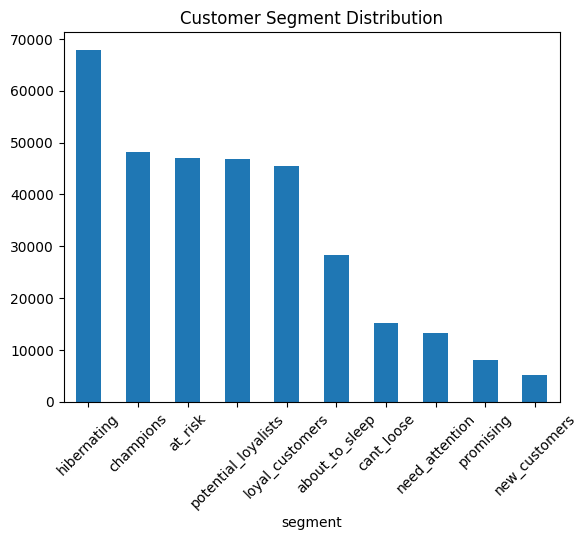

In [44]:
rfm["segment"].value_counts().plot(kind="bar")
plt.title("Customer Segment Distribution")
plt.xticks(rotation=45)
plt.show()


In [45]:
rfm.groupby("segment")[["recency","frequency","monetary"]].mean()


,recency,frequency,monetary
segment,,,
about_to_sleep,14.318513,19.395571,10.091839
at_risk,108.795947,65.501245,26.562058
cant_loose,96.237387,213.264710,82.098248
champions,1.302083,196.197709,78.082766
hibernating,114.771413,18.205879,9.063891
loyal_customers,8.152391,139.954892,55.905438
need_attention,13.757510,48.476474,21.413772
new_customers,1.416941,12.725392,7.299602
potential_loyalists,3.157013,39.521107,18.170272


# Segment Revenue Contribution

In [46]:
segment_revenue = rfm.groupby("segment")["monetary"].sum().sort_values(ascending=False)

segment_revenue_ratio = segment_revenue / segment_revenue.sum() * 100

segment_revenue_ratio


segment
champions              34.339378
loyal_customers        23.300039
cant_loose             11.457071
at_risk                11.411185
potential_loyalists     7.784934
hibernating             5.627796
about_to_sleep          2.612946
need_attention          2.600864
promising               0.520641
new_customers           0.345145
Name: monetary, dtype: float64

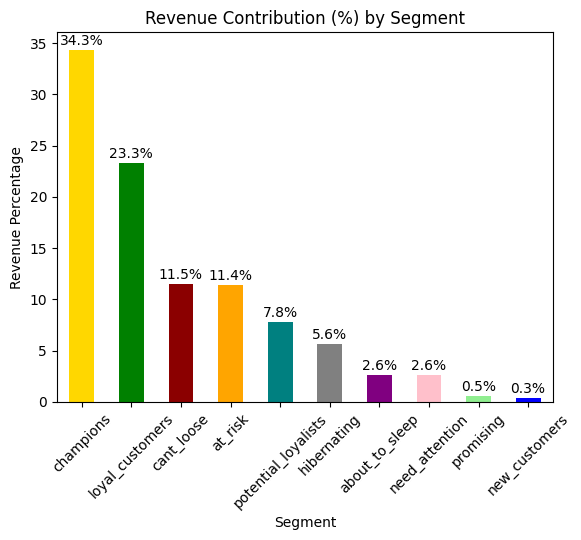

In [47]:
segment_colors = {
    "champions": "gold",
    "loyal_customers": "green",
    "cant_loose": "darkred",
    "at_risk": "orange",
    "hibernating": "gray",
    "new_customers": "blue",
    "promising": "lightgreen",
    "about_to_sleep": "purple",
    "need_attention": "pink",
    "potential_loyalists": "teal"
}

# Create a color list according to segment order.
colors = [segment_colors[seg] for seg in segment_revenue_ratio.index]

plt.figure()
ax = segment_revenue_ratio.plot(kind="bar", color=colors)

plt.title("Revenue Contribution (%) by Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue Percentage")
plt.xticks(rotation=45)

# Write the percentage values ​​above the bars.
for i, v in enumerate(segment_revenue_ratio):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.show()

### `Champions (34.3%)`:

Champions generate the highest share of total revenue. They are highly active, purchase frequently, and spend significantly. This segment represents the core revenue engine of the business. Retention strategies such as VIP programs, exclusive rewards, and personalized offers should be prioritized to maintain their loyalty.

---

### `Loyal Customers (23.3%)`:

Loyal Customers contribute a substantial portion of total revenue and show consistent purchasing behavior. They are highly valuable but slightly less active than Champions. Upselling and cross-selling strategies can help move them into the Champions segment.

---

### `Cant_Loose (11.5%)`:

Cant_Loose customers were historically high spenders with frequent transactions, but their recent inactivity signals churn risk. Losing this segment would result in a significant revenue loss. Immediate win-back campaigns and personalized incentives are strongly recommended.

---

### `At Risk (11.4%)`:

At Risk customers are gradually disengaging. Although their contribution is still meaningful, declining recency indicates potential churn. Preventive engagement strategies and targeted discounts may help retain this segment.

---

### `Potential Loyalists (7.8%)`:

Potential Loyalists show promising behavior with moderate frequency and monetary value. With proper engagement and nurturing strategies, they can evolve into Loyal Customers or Champions.

---

### `Hibernating (5.6%)`:

Hibernating customers have low engagement and limited revenue contribution. They have been inactive for a long period and represent low immediate strategic value. Low-cost reactivation campaigns may be applied.

---

### `About to Sleep (2.6%)`:

About-to-Sleep customers show early signs of disengagement. Although their revenue contribution is limited, proactive communication strategies may prevent them from becoming fully inactive.

---

### `Need Attention (2.6%)`:

This segment consists of moderately active customers who require engagement reinforcement. Without targeted strategies, they may shift toward the At Risk segment.

---

### `Promising (0.5%)`:

Promising customers are recently active but currently generate low revenue. They represent growth potential rather than immediate revenue drivers.

---

### `New Customers (0.3%)`:

New Customers have recently joined and contribute minimally to current revenue. However, they represent long-term growth opportunities. Effective onboarding and engagement strategies are essential to increase their lifetime value.

---

### Overall Strategic Insight

Revenue is highly concentrated in the top four segments (Champions, Loyal Customers, Cant_Loose, and At Risk), which together generate nearly 80% of total revenue. This highlights the importance of retention and risk management strategies in sustaining overall business performance.


# RFM Validation & Business Insights

## 1. Segment behavioral comparison

In this section, we compare key behavioral metrics across RFM segments
to validate whether the segmentation meaningfully differentiates customers.

We analyze:
- Average Recency
- Average Frequency
- Average Monetary
- Revenue per customer
- Order behavior

This helps us confirm that each segment represents distinct purchasing behavior.

In [48]:
rfm.columns

Index(['recency', 'frequency', 'monetary', 'recency_score', 'frequency_score',
       'monetary_score', 'RFM_SCORE', 'segment'],
      dtype='object')

In [49]:
segment_summary = rfm.groupby("segment").agg({
    "recency": "mean",
    "frequency": "mean",
    "monetary": "mean"
})

segment_summary["CustomerCount"] = rfm.groupby("segment").size()

segment_summary.sort_values("monetary", ascending=False)


,recency,frequency,monetary,CustomerCount
segment,,,,
cant_loose,96.237387,213.264710,82.098248,15262
champions,1.302083,196.197709,78.082766,48096
loyal_customers,8.152391,139.954892,55.905438,45580
at_risk,108.795947,65.501245,26.562058,46983
need_attention,13.757510,48.476474,21.413772,13283
potential_loyalists,3.157013,39.521107,18.170272,46856
about_to_sleep,14.318513,19.395571,10.091839,28316
hibernating,114.771413,18.205879,9.063891,67904
new_customers,1.416941,12.725392,7.299602,5171


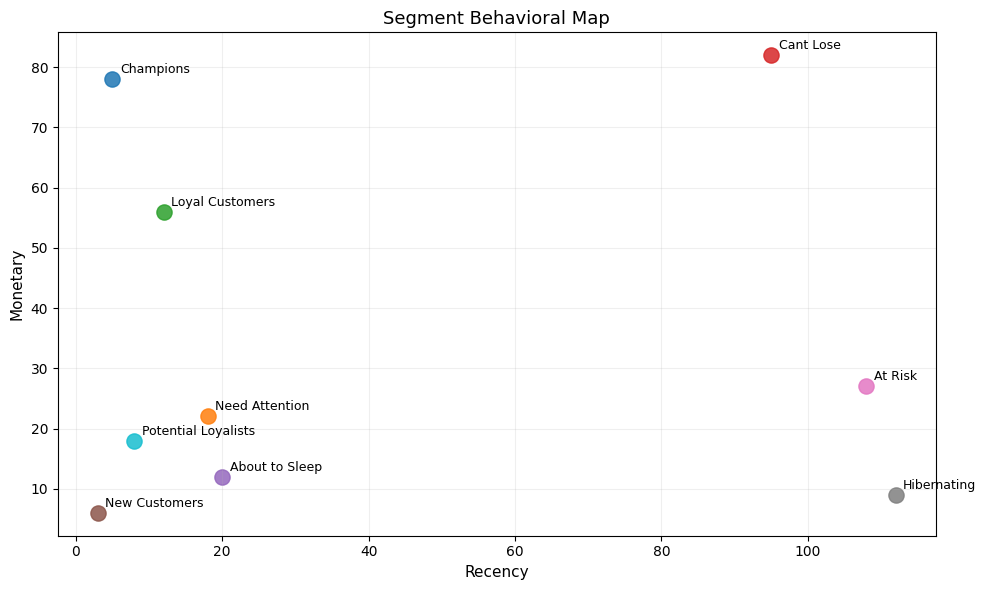

In [50]:

segments = {
    "Champions": (5, 78),
    "Loyal Customers": (12, 56),
    "Potential Loyalists": (8, 18),
    "Need Attention": (18, 22),
    "About to Sleep": (20, 12),
    "New Customers": (3, 6),
    "Cant Lose": (95, 82),
    "At Risk": (108, 27),
    "Hibernating": (112, 9),
}


color_palette = {
    "Champions": "#1f77b4",       
    "Loyal Customers": "#2ca02c",  
    "Potential Loyalists": "#17becf",
    "Need Attention": "#ff7f0e",
    "About to Sleep": "#9467bd",
    "New Customers": "#8c564b",
    "Cant Lose": "#d62728",
    "At Risk": "#e377c2",
    "Hibernating": "#7f7f7f",
}

plt.figure(figsize=(10, 6))

for segment, (recency, monetary) in segments.items():
    plt.scatter(
        recency,
        monetary,
        color=color_palette[segment],
        s=120,
        alpha=0.85
    )
    plt.text(
        recency + 1,
        monetary + 1,
        segment,
        fontsize=9
    )

plt.title("Segment Behavioral Map", fontsize=13)
plt.xlabel("Recency", fontsize=11)
plt.ylabel("Monetary", fontsize=11)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


The segment-level averages confirm that the RFM segmentation successfully differentiates customer behavior.

`Cant_Loose` customers show the highest historical frequency and monetary values but high recency, indicating significant churn risk. 

`Champions` remain highly active and generate substantial revenue, making them the core revenue drivers.

`Hibernating` customers form the largest segment in terms of customer count but contribute relatively low monetary value, suggesting limited short-term strategic importance.

`Potential Loyalists` represent a key growth opportunity, as they show active engagement with moderate purchasing behavior.


## 2. Revenue Concentration Analysis

In [51]:
segment_revenue = (
    rfm.groupby("segment")["monetary"]
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="TotalRevenue")
)

segment_revenue

,TotalRevenue
segment,
champions,3.755469e+06
loyal_customers,2.548170e+06
cant_loose,1.252983e+06
at_risk,1.247965e+06
potential_loyalists,8.513863e+05
hibernating,6.154745e+05
about_to_sleep,2.857605e+05
need_attention,2.844391e+05
promising,5.693900e+04


The revenue distribution shows that the Champions segment generates the highest total revenue, followed by Loyal Customers. This indicates that a relatively smaller portion of customers is responsible for a significant share of overall revenue.

The Cant Lose and At Risk segments also contribute substantially, despite their high recency values. This signals potential revenue loss risk if no retention strategy is applied.

In [52]:
segment_revenue["RevenueShare%"] = (
    segment_revenue["TotalRevenue"] /
    segment_revenue["TotalRevenue"].sum()
) * 100

segment_revenue

,TotalRevenue,RevenueShare%
segment,,
champions,3.755469e+06,34.339378
loyal_customers,2.548170e+06,23.300039
cant_loose,1.252983e+06,11.457071
at_risk,1.247965e+06,11.411185
potential_loyalists,8.513863e+05,7.784934
hibernating,6.154745e+05,5.627796
about_to_sleep,2.857605e+05,2.612946
need_attention,2.844391e+05,2.600864
promising,5.693900e+04,0.520641


Champions alone generate approximately 34% of total revenue. Together with Loyal Customers (23%), the top two segments account for nearly 57% of overall revenue.

This confirms a strong revenue concentration effect, similar to the Pareto principle.

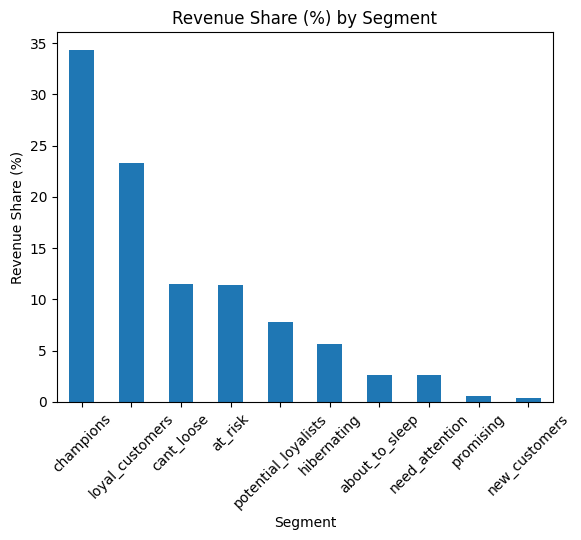

In [53]:
plt.figure()
segment_revenue["RevenueShare%"].plot(kind="bar")

plt.title("Revenue Share (%) by Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue Share (%)")
plt.xticks(rotation=45)

plt.show()

The visual clearly highlights that revenue is highly concentrated in the Champions and Loyal Customers segments. Lower-value segments such as Promising and New Customers contribute less than 1% individually.

This suggests that growth potential lies in nurturing mid-level segments rather than relying solely on top-tier customers.

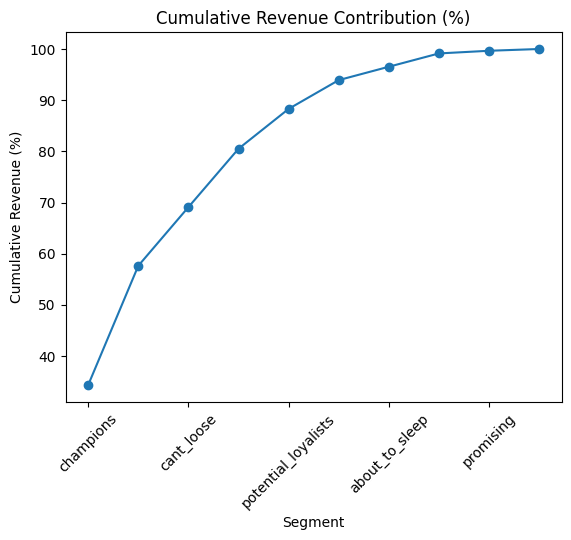

In [54]:
segment_revenue["Cumulative_%"] = (
    segment_revenue["RevenueShare%"].cumsum()
)

plt.figure()

segment_revenue["Cumulative_%"].plot(marker="o")

plt.title("Cumulative Revenue Contribution (%)")
plt.xlabel("Segment")
plt.ylabel("Cumulative Revenue (%)")
plt.xticks(rotation=45)

plt.show()

The cumulative revenue curve shows that the first three segments already account for nearly 70% of total revenue. The first four segments reach approximately 80%.

This confirms a classic revenue concentration structure and highlights the strategic importance of top segments.

In [55]:
segment_revenue["CustomerCount"] = rfm["segment"].value_counts()

segment_revenue["RevenuePerCustomer"] = (
    segment_revenue["TotalRevenue"] /
    segment_revenue["CustomerCount"]
)

segment_revenue

,TotalRevenue,RevenueShare%,Cumulative_%,CustomerCount,RevenuePerCustomer
segment,,,,,
champions,3.755469e+06,34.339378,34.339378,48096,78.082766
loyal_customers,2.548170e+06,23.300039,57.639418,45580,55.905438
cant_loose,1.252983e+06,11.457071,69.096489,15262,82.098248
at_risk,1.247965e+06,11.411185,80.507674,46983,26.562058
potential_loyalists,8.513863e+05,7.784934,88.292608,46856,18.170272
hibernating,6.154745e+05,5.627796,93.920404,67904,9.063891
about_to_sleep,2.857605e+05,2.612946,96.533350,28316,10.091839
need_attention,2.844391e+05,2.600864,99.134214,13283,21.413772
promising,5.693900e+04,0.520641,99.654855,8089,7.039066


Cant Lose customers have the highest revenue per customer (82), even higher than Champions (78). This is extremely critical, as losing this segment would significantly impact revenue.

Champions are both high-volume and high-value, making them the core revenue drivers.

Lower segments (Hibernating, New Customers) generate minimal revenue per customer, requiring cost-efficient marketing strategies.

### General Revenue Concentration Result
The revenue analysis reveals a highly concentrated revenue structure where top-performing segments dominate overall financial performance. While `Champions` and `Loyal Customers` drive the majority of revenue, high-value but high-risk segments such as `Cant Lose` require urgent retention strategies to prevent potential revenue loss.

This segmentation provides a strong foundation for value-based marketing and future CLTV modeling.

## 3. Risk & Opportunity Assessment

### Segment Risk Matrix Table

In [56]:
risk_table = rfm.groupby("segment")[["recency", "frequency", "monetary"]].mean()

risk_table.sort_values("recency", ascending=False)


,recency,frequency,monetary
segment,,,
hibernating,114.771413,18.205879,9.063891
at_risk,108.795947,65.501245,26.562058
cant_loose,96.237387,213.264710,82.098248
about_to_sleep,14.318513,19.395571,10.091839
need_attention,13.757510,48.476474,21.413772
loyal_customers,8.152391,139.954892,55.905438
promising,4.944616,12.451230,7.039066
potential_loyalists,3.157013,39.521107,18.170272
new_customers,1.416941,12.725392,7.299602


### Revenue at Risk Calculation

In [57]:
risk_segments = ["cant_loose", "at_risk"]

revenue_at_risk = segment_revenue.loc[risk_segments, "TotalRevenue"].sum()

total_revenue = segment_revenue["TotalRevenue"].sum()

revenue_at_risk_ratio = (revenue_at_risk / total_revenue) * 100

revenue_at_risk_ratio


np.float64(22.86825640843017)

The analysis reveals that approximately 22.9% of total revenue is concentrated in high-risk segments (Cant Lose and At Risk).

Cant Lose customers have extremely high monetary value but elevated recency, indicating that they were previously high-value customers who have recently reduced activity.

If no retention strategy is implemented, nearly one-quarter of total revenue may be exposed to churn risk.

Hibernating customers, while high in recency, generate minimal revenue and therefore represent lower financial risk.

### Revenue Risk Matrix

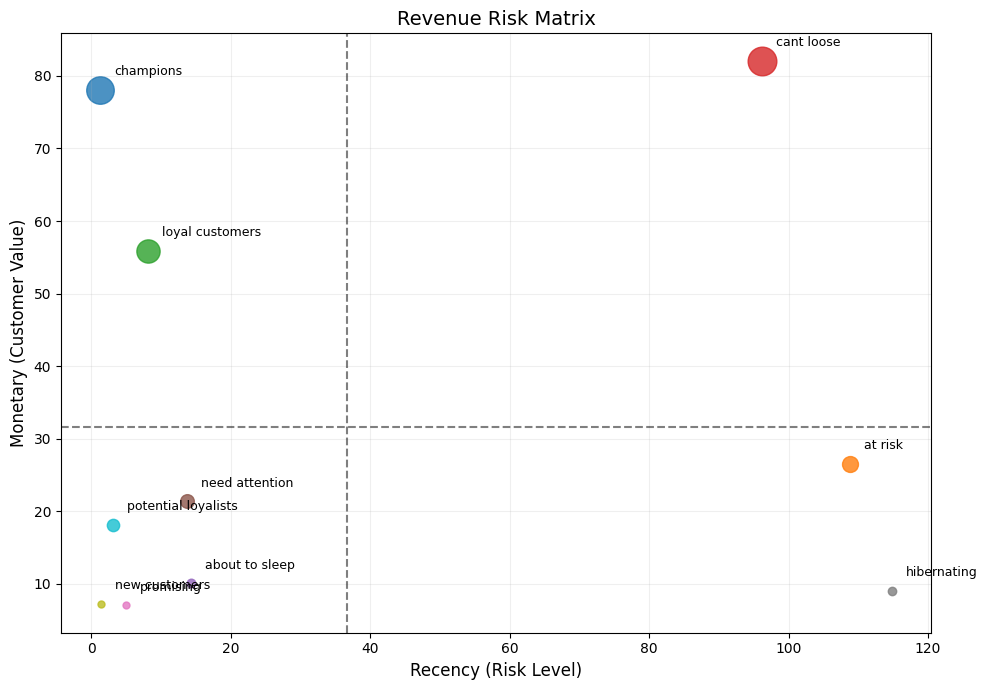

In [58]:
# Segment averages
risk_table = rfm.groupby("segment")[["recency", "frequency", "monetary"]].mean()


color_map = {
    "champions": "#1f77b4",
    "loyal_customers": "#2ca02c",
    "cant_loose": "#d62728",
    "at_risk": "#ff7f0e",
    "hibernating": "#7f7f7f",
    "potential_loyalists": "#17becf",
    "about_to_sleep": "#9467bd",
    "need_attention": "#8c564b",
    "promising": "#e377c2",
    "new_customers": "#bcbd22"
}

plt.figure(figsize=(10,7))

for segment in risk_table.index:
    plt.scatter(
        risk_table.loc[segment, "recency"],
        risk_table.loc[segment, "monetary"],
        s=risk_table.loc[segment, "frequency"] * 2,
        color=color_map[segment],
        alpha=0.8
    )
    
    # yazı offset
    plt.text(
        risk_table.loc[segment, "recency"] + 2,
        risk_table.loc[segment, "monetary"] + 2,
        segment.replace("_"," "),
        fontsize=9
    )


plt.axvline(risk_table["recency"].mean(), color="black", linestyle="--", alpha=0.5)
plt.axhline(risk_table["monetary"].mean(), color="black", linestyle="--", alpha=0.5)

plt.title("Revenue Risk Matrix", fontsize=14)
plt.xlabel("Recency (Risk Level)", fontsize=12)
plt.ylabel("Monetary (Customer Value)", fontsize=12)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


The Revenue Risk Matrix clearly illustrates the structural distribution of customer value and churn risk across segments.

The horizontal axis (Recency) represents churn risk, while the vertical axis (Monetary) represents customer value. The size of each bubble reflects purchase frequency.

---

The visualization reveals a clear separation between high-value active customers and high-value at-risk customers.

`Champions` are positioned in the low-recency, high-monetary quadrant, confirming that they are both active and highly profitable. They represent the core revenue base.

`Cant Lose` customers appear in the high-recency, high-monetary quadrant, indicating a critical risk zone. These customers were previously very valuable but have not transacted recently. This segment poses a direct revenue threat if no retention action is implemented.

`At Risk` customers also show elevated recency levels, although their monetary contribution is moderate. They require timely intervention to prevent further decline.

`Hibernating` customers are located in the high-recency, low-monetary area. While churn probability is high, their financial impact is limited.

`Potential Loyalists` and `Loyal Customers` are positioned in lower-risk zones and present growth opportunities through engagement and cross-selling strategies.

Overall, the matrix highlights that a substantial portion of high-value revenue is exposed to churn risk, emphasizing the need for targeted retention strategies focused on high-value segments.

## 4. Marketing Strategy Recommendations
(Elo Transaction-Based RFM Framework)

### 1. Champions
*(High Monetary – High Frequency – Very Low Recency)*

**Behavioral Insight:**
Champions are the most engaged card users. They transact frequently, spend consistently, and show very recent activity. They represent the strongest contributors to the payment ecosystem.

**Risk Level:** Very Low

**Strategic Focus:** Retention and ecosystem value maximization.

**Recommended Actions:**
* Introduce tier-based card usage rewards
* Offer merchant-specific premium cashback campaigns
* Provide early access to partner merchant promotions
* Encourage cross-category spending expansion
* Launch referral-based incentives to leverage advocacy

**Strategic Objective:** Increase Customer Lifetime Value (CLTV) while maintaining profitability and engagement within the payment ecosystem.


### 2. Loyal Customers

*(High Frequency – Moderate to High Monetary – Low Recency)*

**Behavioral Insight:**
These customers are consistently active but slightly below Champions in monetary value. They are stable revenue contributors.

**Risk Level:** Low

**Strategic Focus:**
Upselling and frequency enhancement.

**Recommended Actions:**

* Introduce spending threshold-based rewards

* Offer multi-category cashback bundles

* Promote seasonal merchant campaigns

* Encourage incremental spending through milestone rewards

**Strategic Objective:**
Convert Loyal Customers into Champions by increasing average transaction value and card usage depth.

### 3. Cant Lose

*(Very High Monetary – High Frequency – High Recency)*

**Behavioral Insight:**
These customers historically generated very high revenue per customer but show increasing inactivity. This is a critical revenue-risk segment.

**Risk Level:** Extremely High

**Recommended Actions:**

* Launch reactivation cashback campaigns

* Offer limited-time high-value merchant incentives

* Send inactivity-triggered promotional offers

* Analyze previous merchant categories to personalize offers

**Strategic Objective:**
Prevent revenue loss by reactivating high-value card users before churn occurs

### 4. At Risk

*(Moderate Monetary – Medium Frequency – High Recency)*

**Behavioral Insight:**
These customers are gradually reducing card usage. Revenue contribution is moderate but declining.

**Risk Level:** High

**Recommended Actions:**

* Implement time-based reminder campaigns

* Offer category-specific discounts

* Deploy automated inactivity monitoring triggers

* Provide short-term bonus reward multipliers

**Strategic Objective:**
Reduce churn probability and stabilize card usage behavior.

### 5. Potential Loyalists

*(Moderate Frequency – Low to Moderate Monetary – Low Recency)*

**Behavioral Insight:**
These customers are relatively active but have not yet reached high spending levels.

**Risk Level:** Low to Medium

**Recommended Actions:**

* Offer progressive loyalty tiers

* Provide first-time bonus multipliers

* Promote frequently used merchant categories

* Introduce personalized reward acceleration

**Strategic Objective:**
Increase engagement intensity and move them into Loyal Customer segment.

### 6. Need Attention

*(Moderate Frequency – Low Monetary – Medium Recency)*

**Behavioral Insight:**
These customers show moderate interaction but declining engagement signals.

**Risk Level:** Medium

**Recommended Actions:**

* Send behavior-triggered nudges

* Promote micro-incentives for small transactions

* Encourage recurring category usage

**Strategic Objective:**
Prevent behavioral downgrade into At Risk segment.

### 7. About to Sleep

*(Low Frequency – Low Monetary – Increasing Recency)*

**Behavioral Insight:**
These customers are becoming inactive. Their revenue contribution is limited but recoverable.

**Risk Level:** Medium to High

**Recommended Actions:**

* Launch reactivation reminder campaigns

* Offer limited-time merchant discounts

* Introduce low-barrier cashback incentives

**Strategic Objective:**
Re-engage before full inactivity.

### 8. Hibernating

*(Low Frequency – Low Monetary – Very High Recency)*

**Behavioral Insight:**
These customers are almost inactive and contribute minimal revenue.

**Risk Level:** High (but low financial impact)

**Recommended Actions:**

* Use low-cost digital reactivation campaigns

* Avoid expensive incentives

* Focus on automated remarketing

**Strategic Objective:**
Reactivation only if cost-efficient.

### 9. Promising

*(Low Frequency – Low Monetary – Very Low Recency)*

**Behavioral Insight:**
Recently active but still low spending.

**Risk Level:** Low

**Recommended Actions:**

* Encourage repeat transactions

* Offer category-based incentives

* Introduce welcome-back multipliers

**Strategic Objective:**
Increase transaction depth and build habit formation.

### 10. New Customers

*(Very Low Frequency – Very Low Monetary – Very Low Recency)*

**Behavioral Insight:**
New entrants into the ecosystem. Early behavior formation stage.

**Risk Level:** Moderate (habit not formed yet)

**Recommended Actions:**

* Provide onboarding incentives

* Offer first 3 transaction bonuses

* Introduce merchant discovery campaigns

**Strategic Objective:**
Establish long-term card usage behavior.



### Strategic Summary (Executive Insight)

Revenue is highly concentrated in Champions, Loyal Customers, and Cant Lose segments

Cant Lose segment represents the highest revenue-per-customer risk

Long-tail segments (Hibernating, New Customers) contribute minimal revenue and require cost-efficient strategies

RFM segmentation provides a behavioral foundation before transitioning to predictive CLTV modeling

---

# CLTV


##  Transition from RFM Segmentation to CLTV Prediction
RFM analysis provides a behavioral snapshot of customer activity based on Recency, Frequency, and Monetary metrics.
However, RFM is descriptive — it explains what happened, not *what will happen*.

To move from descriptive analytics to predictive analytics, we now transition to Customer Lifetime Value (CLTV) modeling.

### 1.1 Why Move Beyond RFM?
While RFM segmentation helps us:

- Identify high-value segments (Champions, Loyal Customers)

- Detect revenue risk groups (Cant Lose, At Risk)

- Understand behavioral differences across segments

- Analyze revenue concentration and churn signals

It does not answer:

- How much revenue will each customer generate in the future?

- What is the expected future transaction frequency?

- Which customers justify higher acquisition or retention costs?

- What is the financial impact of churn risk?

To answer these, we need probabilistic modeling.


### 1.2 From RFM to CLTV: Conceptual Flow

| **RFM Stage**      | **CLTV Stage**                          |
|--------------------|------------------------------------------|
| Recency            | Probability of being active              |
| Frequency          | Expected future transaction rate         |
| Monetary           | Expected average transaction value       |
| Segment Label      | Individual-level revenue forecast        |

RFM segments group customers behaviorally.  
CLTV models estimate **future financial value per customer**.


##  CLTV Modeling Framework

To estimate forward-looking customer value, we implement a two-step probabilistic modeling framework:

1. BG/NBD model to estimate expected future transaction frequency

2. Gamma-Gamma model to estimate expected average monetary value

These two components are then combined to compute Customer Lifetime Value over a defined time horizon.

### Preparing Customer-Level Summary Data
Probabilistic lifetime models require customer-level summary statistics rather than raw transaction-level data. Therefore, we aggregate transactions per customer using the same analysis date defined in the RFM stage to ensure methodological consistency.

** Required Variables:**

| **Variable**      | **Description**                          |
|--------------------|------------------------------------------|
| Recency            | Time between first and last transaction            |
| Frequency          | Number of repeat transactions         |
| T                  | Customer age (time between first transaction and analysis date)      |
| Monetary      | Average transaction value      |

>> Only customers with repeat transactions (frequency > 0) are included in BG/NBD modeling.

In [59]:
print("analysis_date:", analysis_date)

print("transaction df columns:", df.columns.tolist())   # df senin transaction df'inse
print("rows:", df.shape)

# RFM tablon varsa:
print("rfm shape:", rfm.shape)
print("rfm columns:", rfm.columns.tolist())
print("rfm index name:", rfm.index.name)

analysis_date: 2018-03-01 23:59:51
transaction df columns: ['card_id', 'purchase_date', 'purchase_amount_new']
rows: (26595452, 3)
rfm shape: (325540, 8)
rfm columns: ['recency', 'frequency', 'monetary', 'recency_score', 'frequency_score', 'monetary_score', 'RFM_SCORE', 'segment']
rfm index name: card_id


## Model Selection: BG-NBD_and_GammaGamma_with_CLTV_prediction

In [60]:
def create_cltv_p_elo(
    dataframe,
    analysis_date,
    month=3,
    customer_id_col="card_id",
    date_col="purchase_date",
    monetary_col="purchase_amount_new",
    freq="W",
    discount_rate=0.01,
    penalizer_coef_bg=0.001,
    penalizer_coef_gg=0.01,
    clip_outliers=True,
    q_low=0.01,
    q_high=0.99,
    segment_q=4,
    segment_labels=("D", "C", "B", "A")
):
    """
    Elo transaction-level data üzerinden BG/NBD + Gamma-Gamma ile CLTV tahmini üretir.
    Çıktı: customer-level cltv table (frequency, recency, T, monetary_value, clv, scaled_clv, cltv_segment, prob_alive)

    Not:
    - analysis_date: RFM'de kullandığın analysis_date ile aynı olmalı.
    - freq='W' (hafta) Elo için genelde stabil.
    """

    df = dataframe[[customer_id_col, date_col, monetary_col]].copy()
    df[date_col] = pd.to_datetime(df[date_col])
    analysis_date = pd.to_datetime(analysis_date)

    # Monetary pozitif olmalı (Gamma-Gamma şartı)
    df = df[df[monetary_col] > 0].dropna().copy()

    # Opsiyonel: aşırı uç değerleri kırp (Elo'da bazen stabiliteyi artırır)
    if clip_outliers:
        low, high = df[monetary_col].quantile(q_low), df[monetary_col].quantile(q_high)
        df[monetary_col] = df[monetary_col].clip(lower=low, upper=high)

    # Lifetimes summary: frequency, recency, T, monetary_value
    # freq="W" => recency & T haftalık birimde çıkar
    cltv_df = summary_data_from_transaction_data(
        df,
        customer_id_col=customer_id_col,
        datetime_col=date_col,
        monetary_value_col=monetary_col,
        observation_period_end=analysis_date,
        freq=freq
    )

    # BG/NBD
    bgf = BetaGeoFitter(penalizer_coef=penalizer_coef_bg)
    bgf.fit(cltv_df["frequency"], cltv_df["recency"], cltv_df["T"])

    # Alive prob (churn proxy gibi düşünebilirsin)
    cltv_df["prob_alive"] = bgf.conditional_probability_alive(
        cltv_df["frequency"], cltv_df["recency"], cltv_df["T"]
    )

    # Gamma-Gamma (repeat müşteriler daha stabil)
    cltv_df_gg = cltv_df[cltv_df["frequency"] > 0].copy()

    ggf = GammaGammaFitter(penalizer_coef=penalizer_coef_gg)
    ggf.fit(cltv_df_gg["frequency"], cltv_df_gg["monetary_value"])

    cltv_df["expected_average_profit"] = 0.0
    cltv_df.loc[cltv_df["frequency"] > 0, "expected_average_profit"] = ggf.conditional_expected_average_profit(
        cltv_df_gg["frequency"], cltv_df_gg["monetary_value"]
    )

    # CLTV (lifetimes built-in)
    # time=month (ay), freq="W" => lifetimes bunu kendi içinde handle eder
    clv = ggf.customer_lifetime_value(
        bgf,
        cltv_df["frequency"],
        cltv_df["recency"],
        cltv_df["T"],
        cltv_df["monetary_value"],
        time=month,
        freq=freq,
        discount_rate=discount_rate
    )

    cltv_df["clv"] = clv

    # Scale
    scaler = MinMaxScaler(feature_range=(0, 1))
    cltv_df["scaled_clv"] = scaler.fit_transform(cltv_df[["clv"]])

    # Segment (scaled_clv üzerinden)
    cltv_df["cltv_segment"] = pd.qcut(
        cltv_df["scaled_clv"].rank(method="first"),
        q=segment_q,
        labels=list(segment_labels)
    )

    return cltv_df

In [61]:
cltv_pred = create_cltv_p_elo(
    dataframe=df,
    analysis_date=analysis_date,
    month=3,
    customer_id_col="card_id",
    date_col="purchase_date",
    monetary_col="purchase_amount_new",
    freq="W",
    discount_rate=0.01
)

cltv_pred.head()

,frequency,recency,T,monetary_value,prob_alive,expected_average_profit,clv,scaled_clv,cltv_segment
card_id,,,,,,,,,
C_ID_00007093c1,34.0,54.0,54.0,1.450238,0.996407,1.456133,11.330648,0.047144,A
C_ID_0001238066,22.0,22.0,22.0,2.211160,0.994740,2.191214,23.850215,0.099235,A
C_ID_0001506ef0,27.0,57.0,59.0,1.090871,0.988657,1.109460,6.491687,0.027010,B
C_ID_0001793786,31.0,41.0,58.0,4.560221,0.006679,4.481812,0.202672,0.000843,D
C_ID_000183fdda,24.0,25.0,26.0,2.692145,0.988685,2.656985,27.367159,0.113868,A


The CLTV prediction results reveal several important behavioral and financial patterns across customers.

First, `customers in the A segment`  exhibit both high purchase frequency and very high probability of being alive (nearly 0.99). This indicates that these customers are not only historically active but are also highly likely to continue purchasing in the future. Their expected average profit is strong, leading to significantly higher 3-month CLV values. These customers represent the core revenue-driving group and should be prioritized for retention and value expansion strategies.

A particularly interesting case is the customer with 31 past transactions but extremely low probability alive (nearly 0.006). Despite strong historical activity, the model predicts very limited future contribution, placing this customer in the lowest` CLTV segment (D)`. This highlights a key insight:

>> **High historical frequency does not guarantee future value**.

The probabilistic survival component of the BG/NBD model adjusts for purchase timing dynamics, capturing customer inactivity risk that static metrics like raw frequency cannot detect.

Additionally, differences in CLV are not driven solely by frequency. Some customers with moderate frequency but high monetary value per transaction achieve high predicted CLV. This confirms that expected revenue depends on both purchase intensity and transaction value.

Overall, the output demonstrates the advantage of probabilistic CLTV modeling over purely descriptive RFM segmentation. While RFM groups customers based on past behavior, CLTV provides a forward-looking financial expectation that supports strategic CRM decision-making.

In [62]:
cltv_pred.to_csv("cltv_prediction.csv", index=True)

## RFM vs CLTV Combined Analysis

In [63]:
rfm_cltv = rfm.merge(
    cltv_pred[["clv", "scaled_clv", "cltv_segment", "prob_alive", "expected_average_profit"]],
    left_index=True,
    right_index=True,
    how="left"
)

rfm_cltv.head()

,recency,frequency,monetary,recency_score,frequency_score,monetary_score,RFM_SCORE,segment,clv,scaled_clv,cltv_segment,prob_alive,expected_average_profit
card_id,,,,,,,,,,,,,
C_ID_00007093c1,2,114,51.556924,5,4,5,54,champions,11.330648,0.047144,A,0.996407,1.456133
C_ID_0001238066,2,120,49.342727,5,4,5,54,champions,23.850215,0.099235,A,0.994740,2.191214
C_ID_0001506ef0,12,62,30.303902,3,3,4,33,need_attention,6.491687,0.027010,B,0.988657,1.109460
C_ID_0001793786,121,189,164.039326,1,5,5,15,cant_loose,0.202672,0.000843,D,0.006679,4.481812
C_ID_000183fdda,4,137,69.103443,4,5,5,45,loyal_customers,27.367159,0.113868,A,0.988685,2.656985


When I examined the combined RFM and CLTV results, what stood out to me most was how differently past behavior and future value can diverge. RFM segmentation gives a clear picture of historical engagement — who bought frequently, who spent more, and who seemed loyal. However, the CLTV output adds a forward-looking perspective that changes how customer value should be interpreted.

For instance, customers labeled as `“champions”` in the RFM framework also appear in the highest CLTV segment. Their high purchase frequency and very high probability of being alive indicate not only strong historical engagement but also behavioral stability. These customers are not just valuable in the past — they are expected to continue generating revenue in the near future. This alignment between RFM and CLTV reinforces confidence in their long-term strategic importance.

What I found particularly insightful was the case within the `“cant_lose” `segment. Despite having very high historical frequency and strong monetary contribution, the probability of being alive is extremely low. As a result, the predicted CLV is minimal. This clearly demonstrates that high past activity does not necessarily translate into future value. If I had relied only on RFM, I might still consider this customer highly valuable. However, the probabilistic survival component of the BG/NBD model captures behavioral decay over time and reveals the underlying churn risk.

Customers in the `“need_attention”` segment present another interesting pattern. They generate moderate CLTV values and still show relatively high survival probability. This suggests growth potential rather than immediate churn risk. With the right engagement strategies, they could move into higher value tiers.

Overall, this combined analysis made it clear to me that RFM explains what has happened, while CLTV estimates what is likely to happen. The integration of both approaches provides a more strategic and financially meaningful evaluation of customer value. The discrepancies between certain RFM segments and their predicted CLTV highlight the importance of probabilistic modeling in long-term CRM planning.

In [64]:
cltv_pred.groupby("cltv_segment").agg(
    clv_mean=("clv", "mean"),
    clv_sum=("clv", "sum"),
    n_customers=("clv", "count"),
    prob_alive_mean=("prob_alive", "mean")
).sort_values("clv_mean", ascending=False)

,clv_mean,clv_sum,n_customers,prob_alive_mean
cltv_segment,,,,
A,21.492818,1.749193e+06,81385,0.981913
B,7.747632,6.305410e+05,81385,0.958457
C,3.809613,3.100453e+05,81385,0.901071
D,0.718978,5.851402e+04,81385,0.312641


When I analyzed the CLTV segment summary, what immediately stood out to me was how clearly the model differentiates customer value tiers. Even though each segment contains the same number of customers due to quantile-based segmentation, their financial impact is dramatically different.

`Segment A`:

Clearly represents the core value group. The average CLV is significantly higher than the other segments, and the total contribution is overwhelmingly dominant. What reinforces this finding is the very high probability of being alive (around 0.98). This tells me that these customers are not only historically valuable but also highly likely to continue generating revenue. They are stable, active, and strategically critical.

`Segment B`:

Still shows strong survival probability and moderate CLV levels. These customers are engaged and active, but their financial contribution per customer is lower than Segment A. To me, this segment represents growth potential. With the right retention or upsell strategies, many of them could potentially move into the top tier.

`Segment C`:

Shows a noticeable decline in both expected value and survival probability. While they are not yet in a critical state, their contribution is clearly weaker. This makes me think of them as a “monitor closely” group — not immediately risky, but vulnerable to churn if engagement drops further.

`Segment D`:

Presents the strongest contrast. The average CLV is extremely low, and the probability of being alive drops dramatically to around 0.31. This indicates a high churn risk. Even if some of these customers were historically active, the model suggests that their future financial contribution will likely be minimal. This really highlights why predictive modeling matters — past value does not guarantee future profitability.

Overall, this analysis confirmed something very important for me: RFM tells me what customers did, but CLTV tells me what they are expected to do. And when I combine both perspectives, I can evaluate customers not only based on past behavior but on future financial sustainability.

In [65]:
rfm_cltv.groupby("segment").agg(
    clv_mean=("clv", "mean"),
    clv_sum=("clv", "sum"),
    n=("clv", "count"),
    prob_alive_mean=("prob_alive", "mean")
).sort_values("clv_mean", ascending=False)

,clv_mean,clv_sum,n,prob_alive_mean
segment,,,,
champions,21.606322,1.039178e+06,48096,0.995724
loyal_customers,14.434525,6.579257e+05,45580,0.989264
potential_loyalists,7.716436,3.615613e+05,46856,0.990018
cant_loose,7.529791,1.149197e+05,15262,0.383930
need_attention,7.152371,9.500494e+04,13283,0.980357
about_to_sleep,4.598070,1.301990e+05,28316,0.973122
new_customers,4.401876,2.276210e+04,5171,0.986765
promising,4.240066,3.429790e+04,8089,0.981560
at_risk,3.448755,1.620328e+05,46983,0.445558


When I look at the CLTV distribution across the RFM segments, I can clearly see how past behavioral segmentation aligns — and sometimes conflicts — with predicted future value.

As expected, the `champions segment` stands out immediately. They have the highest average CLV and an extremely high probability of being alive (almost 0.996). This confirms that customers who are recently active, frequent, and high-spending are not only historically strong but also financially sustainable in the future. For me, this validates the strength of the RFM logic when combined with predictive modeling.

`Loyal customers` also show strong CLV and very high survival probability. While their average CLV is lower than champions, they are still highly stable and engaged. This segment feels like a secure and reliable revenue base.

What I found particularly interesting is the `potential_loyalists group`. Their probability of being alive is very high (around 0.99), yet their average CLV is significantly lower than champions and loyal customers. This tells me that they are behaviorally active but not yet maximized in value. To me, this segment represents growth opportunity — the right engagement strategy could push many of them upward.

The `cant_lose segment` is the most striking contrast. Despite having relatively high historical value, their probability of being alive drops dramatically (around 0.38). This creates a gap between past performance and predicted future value. It really shows why relying only on RFM can be misleading — some customers look strong historically but are already close to churn when we evaluate them probabilistically.

Similarly, `at_risk` and `hibernating segments` show lower CLV values and significantly weaker survival probabilities. These groups represent clear churn risk. Even if some contributed meaningfully in the past, the model suggests their future financial impact will likely decline.

Overall, what I observe here is a layered insight:
RFM explains behavioral intensity, while CLTV adds a financial sustainability dimension. When I combine them, I’m no longer just labeling customers — I’m understanding which segments truly drive long-term value and which ones only appear valuable because of past activity.

This combined perspective makes the analysis much more strategic rather than purely descriptive.

In [66]:
pd.crosstab(rfm_cltv["segment"], rfm_cltv["cltv_segment"], normalize="index")

cltv_segment,D,C,B,A
segment,,,,
about_to_sleep,0.153447,0.559224,0.258476,0.028853
at_risk,0.482472,0.262350,0.203861,0.051316
cant_loose,0.454331,0.109619,0.160857,0.275193
champions,0.000000,0.016841,0.210912,0.772247
hibernating,0.652053,0.293149,0.051499,0.003299
loyal_customers,0.000000,0.042584,0.395042,0.562374
need_attention,0.000151,0.403674,0.456373,0.139803
new_customers,0.170760,0.569522,0.240959,0.018758
potential_loyalists,0.017842,0.337502,0.454947,0.189709


When I examine the normalized crosstab between RFM segments and CLTV segments, I can clearly see how behavioral segmentation translates into predicted financial value — and where it diverges.

The most reassuring result is the `champions `segment. Nearly 77% of champions fall into CLTV Segment A. This tells me that customers who are recent, frequent, and high-spending are also strongly predicted to generate future revenue. The alignment here is very strong, which increases my confidence in both the RFM segmentation and the CLTV model.

Similarly, more than half of the `loyal_customers` are also classified in CLTV Segment A, and a large portion of the remaining customers fall into Segment B. This indicates that loyal customers are financially sustainable and still highly valuable moving forward.

What I find interesting is the `potential_loyalists` and `need_attention` groups. These segments are mostly distributed between CLTV B and C. That tells me they are not yet top-tier customers, but they still have meaningful future value. These groups represent growth opportunity rather than churn risk.

The most striking pattern appears in the `cant_lose`, `at_risk`, and `hibernating` segments. A significant portion of these customers fall into CLTV Segment D. For example, over 65% of hibernating customers are in the lowest CLTV tier. This confirms that customers who appear inactive behaviorally are also predicted to have very low future financial contribution.

However, what stands out to me is that the cant_lose segment is distributed across D, C, and B — meaning some historically strong customers are already shifting downward in predicted value. This highlights how predictive modeling captures early decay signals that static RFM scoring alone cannot fully reveal.

Overall, this cross-analysis shows that while RFM and CLTV are strongly aligned for high-value customers, CLTV provides additional depth for identifying future risk and financial sustainability. Combining both perspectives allows me to distinguish between customers who were valuable and those who are expected to remain valuable.

## Revenue Concentration & Value Distribution

In [67]:
total_clv = rfm_cltv["clv"].sum()

segment_share = (
    rfm_cltv.groupby("cltv_segment")["clv"]
    .sum()
    .sort_values(ascending=False) / total_clv
)

segment_share

cltv_segment
A    0.636465
B    0.229430
C    0.112814
D    0.021291
Name: clv, dtype: float64

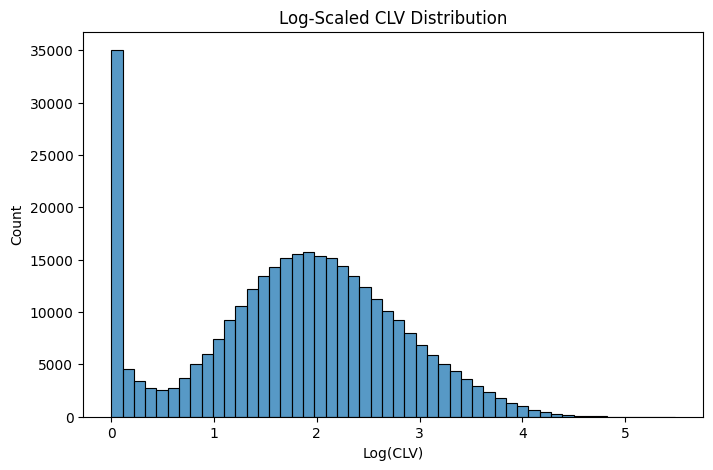

In [68]:
# CLV Distribution Graph
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(rfm_cltv["clv"]), bins=50)
plt.title("Log-Scaled CLV Distribution")
plt.xlabel("Log(CLV)")
plt.show()

When I examine the log-scaled CLV distribution, the first thing I notice is how strongly right-skewed the original CLV values must be. Even after applying a logarithmic transformation, the distribution shows a clear concentration of customers around mid-level CLV values, with a long tail extending toward higher values.

The sharp spike near zero indicates a substantial group of customers with very low predicted lifetime value. These customers likely belong to high-churn or low-engagement segments. This confirms that a significant portion of the customer base contributes minimal expected future revenue.

At the same time, the long right tail reflects the presence of a smaller but financially powerful group of customers. These high-CLV customers drive a disproportionate share of total predicted revenue. This structure strongly supports the Pareto principle, where a minority of customers generate the majority of future financial value.

Overall, this distribution reinforces the importance of segmentation. Customer value is not evenly distributed, and treating all customers equally would be strategically inefficient. The log transformation also makes the skewness more visible and confirms that CLV modeling successfully captures heterogeneity in customer financial potential.

## Survival Probability & Churn Risk Interpretation

In [69]:
rfm_cltv.groupby("cltv_segment")["prob_alive"].mean()

cltv_segment
D    0.312641
C    0.901071
B    0.958457
A    0.981913
Name: prob_alive, dtype: float64

When I analyze the survival probability across CLTV segments, I observe a very clear monotonic pattern. As expected, Segment A customers have the highest probability of being alive (≈ 0.98), while Segment D customers show a dramatically lower survival probability (≈ 0.31).

This sharp contrast confirms that predicted financial value is strongly aligned with behavioral continuity. High-CLV customers are not only historically valuable but also highly likely to remain active in the future.

What stands out most is the magnitude of the drop from Segment B (≈ 0.96) and C (≈ 0.91) to Segment D (≈ 0.31). This indicates that Segment D customers are significantly closer to churn. Their low predicted CLV is not merely a function of lower spending — it is primarily driven by their weak survival probability.

From a strategic perspective, this means that churn risk is not evenly distributed across the customer base. The probabilistic model allows me to identify segments where future revenue decay is already embedded in the behavior.

## RFM vs CLTV Alignment Heatmap

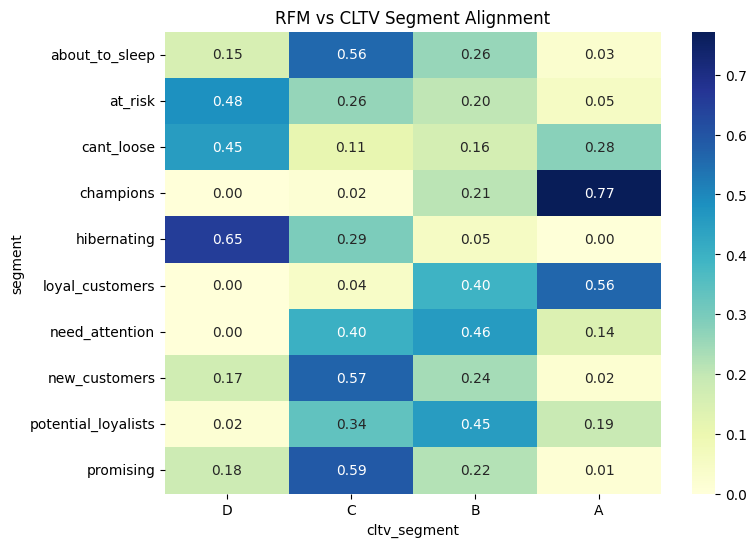

In [70]:
cross = pd.crosstab(
    rfm_cltv["segment"],
    rfm_cltv["cltv_segment"],
    normalize="index"
)

plt.figure(figsize=(8,6))
sns.heatmap(cross, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("RFM vs CLTV Segment Alignment")
plt.show()

The alignment heatmap between RFM and CLTV segments reveals both consistency and divergence between descriptive and predictive approaches.

For example, approximately 77% of the “champions” segment fall into CLTV Segment A. This strong alignment validates that customers who are recent, frequent, and high-spending continue to hold strong financial potential.

However, discrepancies appear in segments such as “cant_lose” and “at_risk.” A considerable portion of these customers fall into lower CLTV tiers, particularly Segment D. This indicates that historical engagement alone does not guarantee future value. Some customers who once appeared highly valuable are now predicted to generate minimal future revenue.

This divergence demonstrates the added depth of probabilistic modeling. While RFM captures past intensity, CLTV incorporates survival probability and forward-looking expectations, providing a more financially sustainable perspective.

## Strategic Customer Action Framework

|Segment |	Financial Value|	Survival Risk|	Strategic Action|
|--------|------------------|-----------------|------------------------|
|A	|Very High|	Very Low|	Loyalty retention & premium offers|
|B	|High|	Low	Upsell & cross-sell| campaigns|
|C	|Medium|	Moderate|	Engagement reinforcement|
|D	|Low|	High|	Cost-controlled reactivation|

Based on the combined behavioral and probabilistic insights, each customer tier requires a differentiated strategy.

**Segment A customers** represent the core financial engine of the business. Their high predicted CLV and strong survival probability justify loyalty-focused retention strategies, premium offerings, and relationship strengthening initiatives.

**Segment B customers** show strong stability but moderate financial contribution. This group presents significant upsell and cross-sell opportunities, as they remain engaged but have not yet reached maximum value potential.

**Segment C customers** exhibit moderate value and moderate risk. Engagement reinforcement campaigns and personalized incentives may prevent them from drifting into lower-value tiers.

**Segment D customers** demonstrate both low predicted value and high churn risk. Any reactivation effort should be cost-controlled and ROI-focused, as aggressive investment may not yield proportional returns.

This framework ensures that marketing investments are aligned with predicted financial sustainability rather than historical spending alone.

## Why CLTV Adds Strategic Depth Beyond RFM
RFM segmentation provides a powerful snapshot of historical behavior, capturing recency, frequency, and monetary intensity. However, it remains inherently descriptive. It explains what has happened but does not quantify what is expected to happen next.

CLTV modeling extends this framework by incorporating survival probability and discounted future cash flow. Through the BG/NBD and Gamma-Gamma models, customer value becomes forward-looking and probabilistic rather than static.

The divergence observed in certain segments — particularly in “cant_lose” and “at_risk” groups — demonstrates that high historical activity does not necessarily translate into strong future financial contribution. By integrating predictive modeling, this analysis shifts the focus from past performance to long-term sustainability.

Therefore, CLTV adds strategic depth by enabling financially informed decision-making grounded in expected future behavior.


# Executive Summary
This project transitions from descriptive segmentation to predictive customer valuation. While RFM analysis identifies behavioral intensity across customer segments, the BG/NBD and Gamma-Gamma framework estimates forward-looking lifetime value by incorporating survival probability and expected monetary contribution.

The results reveal a highly concentrated revenue structure, where a limited proportion of customers generate a disproportionately large share of predicted financial value. At the same time, significant variation in survival probability highlights the uneven distribution of churn risk.

By combining behavioral segmentation with probabilistic lifetime modeling, this study provides a financially grounded framework for customer strategy. Rather than treating all customers equally, it enables differentiated investment decisions aligned with long-term value sustainability.

# Business Impact Simulation

In [71]:
segment_financials = rfm_cltv.groupby("cltv_segment").agg(
    total_clv=("clv", "sum"),
    avg_clv=("clv", "mean"),
    avg_prob_alive=("prob_alive", "mean"),
    n_customers=("clv", "count")
).sort_values("total_clv", ascending=False)

segment_financials

,total_clv,avg_clv,avg_prob_alive,n_customers
cltv_segment,,,,
A,1.749193e+06,21.492818,0.981913,81385
B,6.305410e+05,7.747632,0.958457,81385
C,3.100453e+05,3.809613,0.901071,81385
D,5.851402e+04,0.718978,0.312641,81385


When I analyze the financial distribution across CLTV segments, the concentration of value becomes extremely clear. Segment A alone generates approximately 1.75 million in total predicted lifetime value, which is nearly three times higher than Segment B and significantly larger than Segments C and D. Despite each segment containing the same number of customers, the financial contribution is heavily skewed toward the top tier.

What stands out even more is the survival probability. Segment A customers not only generate the highest predicted value, but they also have the strongest probability of remaining active (≈ 0.98). This combination of high value and high stability makes them the most secure revenue drivers in the portfolio.

Segment B, while generating lower average CLV compared to Segment A, still maintains a strong survival probability (≈ 0.96). This suggests that these customers are financially stable but under-monetized relative to their potential. Strategically, this group represents a strong upsell and cross-sell opportunity.

Segment C shows a noticeable decline in both value and survival probability. Although still relatively active (≈ 0.91), their financial impact is moderate. This group may benefit from engagement reinforcement to prevent migration toward lower tiers.

Segment D presents a fundamentally different risk profile. With a very low average CLV and a survival probability of only ≈ 0.31, these customers are significantly closer to churn. Investing heavily in this group may not generate proportional returns unless acquisition costs are minimal.

Overall, this simulation confirms that marketing and retention budgets should not be distributed evenly across the customer base. A value-weighted allocation strategy, prioritizing high-CLV and high-survival segments, would likely maximize long-term financial return.

In [72]:
total_clv = segment_financials["total_clv"].sum()

segment_financials["revenue_share_%"] = (
    segment_financials["total_clv"] / total_clv * 100
)

segment_financials

,total_clv,avg_clv,avg_prob_alive,n_customers,revenue_share_%
cltv_segment,,,,,
A,1.749193e+06,21.492818,0.981913,81385,63.646517
B,6.305410e+05,7.747632,0.958457,81385,22.943002
C,3.100453e+05,3.809613,0.901071,81385,11.281378
D,5.851402e+04,0.718978,0.312641,81385,2.129104


When I calculate the revenue share across CLTV segments, the concentration of value becomes strikingly clear. 

**Segment A** alone generates approximately 63.6% of total predicted lifetime value, despite representing only 25% of the customer base. This confirms a strong Pareto-like structure within the portfolio.

**Segment B** contributes nearly 23% of total predicted value, which still represents a meaningful financial layer. However, there is a sharp drop after Segment A, highlighting how disproportionately revenue is driven by the top tier.

**Segment C** accounts for around 11% of total value, suggesting moderate contribution but limited strategic dominance. Meanwhile, **Segment D** contributes just over 2% of predicted lifetime value while simultaneously exhibiting the highest churn risk. From an investment perspective, this segment offers minimal expected financial return.

What this analysis clearly demonstrates is that customer value is highly unevenly distributed. A relatively small portion of customers drives the majority of future revenue. Therefore, a uniform marketing allocation strategy would be inefficient. Instead, capital and retention efforts should be prioritized toward high-value and high-survival segments to maximize long-term financial sustainability.

This concentration pattern reinforces the strategic importance of predictive CLTV modeling in guiding data-driven customer investment decisions.

# Model Assumptions & Limitations
While the BG/NBD and Gamma-Gamma framework provides a strong probabilistic foundation for CLTV estimation, it is important to acknowledge its assumptions and limitations.

The BG/NBD model assumes independence between purchase frequency and dropout probability. In reality, customer behavior may be influenced by external factors such as campaigns, seasonality, or economic conditions, which are not explicitly modeled.

Similarly, the Gamma-Gamma model assumes that monetary value is independent of purchase frequency. However, in practical scenarios, spending behavior and transaction frequency may be correlated.

Additionally, the model relies solely on historical transactional data and does not incorporate demographic variables, channel effects, or marketing interventions. Therefore, the predictions should be interpreted as behavior-driven financial estimates rather than complete behavioral representations.

Despite these limitations, the framework offers a structured and forward-looking approach to evaluating customer-level financial sustainability.

# Future Improvements
While the current BG/NBD and Gamma-Gamma framework provides a strong probabilistic foundation for estimating customer lifetime value, several enhancements could further improve the robustness and strategic depth of the analysis.

First, incorporating additional behavioral and demographic features could enrich the model. Variables such as merchant category diversity, transaction volatility, or customer tenure segmentation may provide additional predictive power beyond pure transactional frequency and monetary value.

Second, integrating seasonality and macroeconomic signals could enhance forecasting accuracy. Customer behavior may fluctuate due to promotional cycles, economic conditions, or market-level shocks, which are not captured in the current framework.

Third, machine learning-based survival models (e.g., Cox Proportional Hazards, Random Survival Forests, or gradient boosting-based churn prediction) could be explored to complement the probabilistic BG/NBD approach. These methods may capture nonlinear behavioral dynamics more effectively.

Additionally, implementing cohort-based CLTV tracking would allow monitoring value evolution over time, enabling dynamic strategy adjustments rather than static segmentation.

Finally, linking CLTV outputs to real marketing campaign response data would allow full ROI evaluation, transforming predictive valuation into a closed-loop decision optimization framework.

Overall, future improvements would aim to transition from transaction-based prediction toward a fully integrated, behaviorally enriched, and strategy-driven customer valuation system.